https://www.learnpytorch.io/08_pytorch_paper_replicating/

In [15]:
import os
import math
import time
import torch
import random
import numpy as np
import torchvision
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

# Set random seed
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

def time_it(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"Execution time : {end - start:.2f} seconds")
        return result
    return wrapper

In [16]:
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
)

In [17]:
batch_size = 32
train_shuffle = True
test_shuffle = False
patch_size = 4
embed_dim = 128
in_channel = 1
eps = 1e-5
n_blocks = 10
n_classes = 10
img_size = 28
num_head = 16
dropout_rate = 0
compile_mode = "max-autotune"
compile_backend = "inductor"

In [18]:
train_prep = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.485, ), std=(0.229, )),
    v2.Grayscale()
])

test_prep = v2.Compose([
    v2.ToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.485, ), std=(0.229, )),
    v2.Grayscale()
])

def train_collate_fn(batch):
    images, labels = zip(*batch)
    prep_images = torch.stack([train_prep(i) for i in images])
    return prep_images, torch.tensor(labels, dtype=torch.long)

def test_collate_fn(batch):
    images, labels = zip(*batch)
    prep_images = torch.stack([test_prep(i) for i in images])
    return prep_images, torch.tensor(labels, dtype=torch.long)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [19]:
train_dl = DataLoader(dataset=train_dataset,
                      batch_size=batch_size,
                      shuffle=train_shuffle,
                      num_workers=os.cpu_count(),
                      collate_fn=train_collate_fn)

test_dl = DataLoader(dataset=test_dataset,
                     batch_size=batch_size,
                     shuffle=test_shuffle,
                     num_workers=os.cpu_count(),
                     collate_fn=test_collate_fn)

In [20]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size, embed_dim, in_channel):
        super(PatchEmbedding, self).__init__()
        self.patch = nn.Conv2d(in_channels=in_channel, out_channels=embed_dim,
                               stride=patch_size, kernel_size=patch_size)
        nn.init.trunc_normal_(self.patch.weight, std=0.02)
        if self.patch.bias is not None:
            nn.init.zeros_(self.patch.bias)

    def forward(self, x):
        x = self.patch(x)  # (batch_size, embed_dim, H/patch_size, W/patch_size)
        x = x.flatten(2).transpose(1, 2)
        return x  # (batch_size, seq_length, embed_dim)

class LayerNorm(nn.Module):
    def __init__(self, embed_dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(embed_dim))
        self.bias = nn.Parameter(torch.zeros(embed_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.weight * (x - mean) / torch.sqrt(var + self.eps) + self.bias

class Gelu(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            math.sqrt(2 / math.pi) * (x + 0.044715 * x ** 3)
        ))

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_head=8, bias=True, dropout_rate=0.0):
        super().__init__()
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=bias)

        assert embed_dim % num_head == 0, "embed_dim % num_head != 0"
        self.d_k = embed_dim // num_head
        self.num_head = num_head
        self.dropout = nn.Dropout(dropout_rate)
        self.W_o = nn.Linear(embed_dim, embed_dim, bias=bias)

        for layer in [self.W_q, self.W_k, self.W_v, self.W_o]:
            nn.init.trunc_normal_(layer.weight, std=0.02)
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        batch_size, seq_length, embed_dim = x.size()

        q = self.W_q(x).view(batch_size, seq_length, self.num_head, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(batch_size, seq_length, self.num_head, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(batch_size, seq_length, self.num_head, self.d_k).transpose(1, 2)

        attention = self.dropout(
            F.softmax(q @ k.transpose(-2, -1) / math.sqrt(self.d_k), dim=-1)
        ) @ v

        out = self.W_o(attention.transpose(1, 2).contiguous().view(batch_size, seq_length, -1))
        return out

class MLP(nn.Module):
    def __init__(self, embed_dim, dropout_rate=0.0):
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, 4 * embed_dim)
        self.gelu = Gelu()
        self.fc2 = nn.Linear(4 * embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout_rate)

        nn.init.trunc_normal_(self.fc1.weight, std=0.02)
        nn.init.trunc_normal_(self.fc2.weight, std=0.02)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_head=8, dropout_rate=0.0):
        super().__init__()
        self.layernorm_1 = LayerNorm(embed_dim)
        self.layernorm_2 = LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, dropout_rate)
        self.mha = MultiHeadAttention(embed_dim, num_head, dropout_rate=dropout_rate)

    def forward(self, x):
        # Pre-norm architecture
        shortcut = x
        x = self.layernorm_1(x)
        x = self.mha(x)
        x = x + shortcut

        shortcut = x
        x = self.layernorm_2(x)
        x = self.mlp(x)
        x = x + shortcut
        return x

class ViT(nn.Module):
    def __init__(self, img_size=img_size, patch_size=patch_size, in_channel=in_channel, n_classes=n_classes,
                 embed_dim=embed_dim, n_blocks=n_blocks, num_head=num_head, dropout_rate=dropout_rate):
        super().__init__()

        self.patch_embedding = PatchEmbedding(patch_size=patch_size,
                                             embed_dim=embed_dim,
                                             in_channel=in_channel)

        # Calculate number of patches
        num_patches = (img_size // patch_size) ** 2

        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Positional embeddings
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        self.dropout = nn.Dropout(dropout_rate)

        # Transformer blocks
        self.block = nn.Sequential(*[
            TransformerEncoder(embed_dim, num_head, dropout_rate)
            for _ in range(n_blocks)
        ])

        # Classification head
        self.mlp_head = nn.Sequential(
            LayerNorm(embed_dim),
            nn.Linear(embed_dim, n_classes)
        )

        nn.init.trunc_normal_(self.mlp_head[1].weight, std=0.02)
        nn.init.zeros_(self.mlp_head[1].bias)

    def forward(self, x):
        batch_size = x.size(0)

        # Patch embedding
        patch_embed = self.patch_embedding(x)

        # Add CLS token
        cls_token = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_token, patch_embed), dim=1)

        # Add positional embeddings
        x = x + self.pos_embedding
        x = self.dropout(x)

        # Transformer blocks
        x = self.block(x)

        # Classification head
        cls_output = x[:, 0]
        logits = self.mlp_head(cls_output)
        return logits

In [21]:
vit_model = torch.compile(ViT(), mode=compile_mode, backend=compile_backend)


vit_model

OptimizedModule(
  (_orig_mod): ViT(
    (patch_embedding): PatchEmbedding(
      (patch): Conv2d(1, 128, kernel_size=(4, 4), stride=(4, 4))
    )
    (dropout): Dropout(p=0, inplace=False)
    (block): Sequential(
      (0): TransformerEncoder(
        (layernorm_1): LayerNorm()
        (layernorm_2): LayerNorm()
        (mlp): MLP(
          (fc1): Linear(in_features=128, out_features=512, bias=True)
          (gelu): Gelu()
          (fc2): Linear(in_features=512, out_features=128, bias=True)
          (dropout): Dropout(p=0, inplace=False)
        )
        (mha): MultiHeadAttention(
          (W_q): Linear(in_features=128, out_features=128, bias=True)
          (W_k): Linear(in_features=128, out_features=128, bias=True)
          (W_v): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0, inplace=False)
          (W_o): Linear(in_features=128, out_features=128, bias=True)
        )
      )
      (1): TransformerEncoder(
        (layernorm_1): Laye

In [22]:
class Trainer:
    def __init__(self,
                 optimizer,
                 model,
                 loss,
                 train_dl,
                 val_dl,
                 lr_scheduler,
                 patience,
                 device="cuda:0" if torch.cuda.is_available() else "cpu"):
        self.loss = loss
        self.device = device
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.lr_scheduler = lr_scheduler
        self.model = model.to(device)
        self.optimizer = optimizer
        self.patience = patience
        self.best_val_loss = float("inf")
        self.counter = 0

    def train(self, train_dl):
        total_loss = 0
        total_accuracy = 0

        self.model.train()
        for X, y in train_dl:
            X, y = X.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()
            logits = self.model(X)
            loss = self.loss(logits, y)
            total_loss += loss.item()
            total_accuracy += accuracy_score(y.cpu().numpy(),
                                             torch.argmax(logits, dim=1).cpu().numpy())
            loss.backward()
            self.optimizer.step()

        return total_loss / len(train_dl), total_accuracy / len(train_dl)

    def eval(self, val_dl):
        total_loss = 0
        total_accuracy = 0

        self.model.eval()

        with torch.no_grad():
            for X, y in val_dl:
                X, y = X.to(self.device), y.to(self.device)
                logits = self.model(X)
                loss = self.loss(logits, y)
                total_loss += loss.item()
                total_accuracy += accuracy_score(y.cpu().numpy(),
                                                 torch.argmax(logits, dim=1).cpu().numpy())

        return total_loss / len(val_dl), total_accuracy / len(val_dl)

    def fit(self, n_epochs):
        data = {"train_loss":[], "train_accuracy":[],
                "eval_loss":[], "eval_accuracy":[]}
        for epoch in range(n_epochs):
            train_loss, train_accuracy = self.train(self.train_dl)
            val_loss, val_accuracy = self.eval(self.val_dl)

            print(f"Epoch [{epoch+1}/{n_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

            self.lr_scheduler.step(val_loss)

            data["train_loss"].append(train_loss)
            data["train_accuracy"].append(train_accuracy)
            data["eval_loss"].append(val_loss)
            data["eval_accuracy"].append(val_accuracy)

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.counter = 0
                torch.save(self.model.state_dict(), "best_vit.pth")
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                    break

        return data

In [23]:
loss = torch.nn.CrossEntropyLoss()
optim = torch.optim.RMSprop(params=vit_model.parameters(), lr=1e-5)
scheduler = ReduceLROnPlateau(optimizer=optim, mode="min", factor=0.5, patience=2)

In [24]:
trainer = Trainer(model=vit_model,
                  optimizer=optim,
                  loss=loss,
                  train_dl=train_dl,
                  val_dl=test_dl,
                  patience=5,
                  lr_scheduler=scheduler)

In [25]:
@time_it
def fit_model(n_epochs):
    return trainer.fit(n_epochs=n_epochs)

In [26]:
history = fit_model(n_epochs=100)

Epoch [1/100] Train Loss: 1.7879, Train Acc: 0.3617 | Val Loss: 1.5713, Val Acc: 0.4431
Epoch [2/100] Train Loss: 1.2411, Train Acc: 0.5826 | Val Loss: 0.9708, Val Acc: 0.6987
Epoch [3/100] Train Loss: 0.8520, Train Acc: 0.7240 | Val Loss: 0.8117, Val Acc: 0.7222
Epoch [4/100] Train Loss: 0.6470, Train Acc: 0.7880 | Val Loss: 0.5599, Val Acc: 0.8163
Epoch [5/100] Train Loss: 0.5387, Train Acc: 0.8197 | Val Loss: 0.4684, Val Acc: 0.8467
Epoch [6/100] Train Loss: 0.4759, Train Acc: 0.8371 | Val Loss: 0.4429, Val Acc: 0.8531
Epoch [7/100] Train Loss: 0.4311, Train Acc: 0.8534 | Val Loss: 0.4173, Val Acc: 0.8628
Epoch [8/100] Train Loss: 0.3974, Train Acc: 0.8642 | Val Loss: 0.3724, Val Acc: 0.8748
Epoch [9/100] Train Loss: 0.3710, Train Acc: 0.8724 | Val Loss: 0.3322, Val Acc: 0.8858
Epoch [10/100] Train Loss: 0.3466, Train Acc: 0.8809 | Val Loss: 0.3359, Val Acc: 0.8845
Epoch [11/100] Train Loss: 0.3292, Train Acc: 0.8861 | Val Loss: 0.3305, Val Acc: 0.8882
Epoch [12/100] Train Loss: 0.3

In [27]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['eval_loss'], label='Validation Loss', marker='s')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Plot Accuracy
    axes[1].plot(history['train_accuracy'], label='Train Accuracy', marker='o')
    axes[1].plot(history['eval_accuracy'], label='Validation Accuracy', marker='s')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"Final Training Results:")
    print(f"{'='*50}")
    print(f"Best Validation Loss: {min(history['eval_loss']):.4f}")
    print(f"Best Validation Accuracy: {max(history['eval_accuracy']):.4f}")
    print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
    print(f"Final Training Accuracy: {history['train_accuracy'][-1]:.4f}")
    print(f"{'='*50}\n")

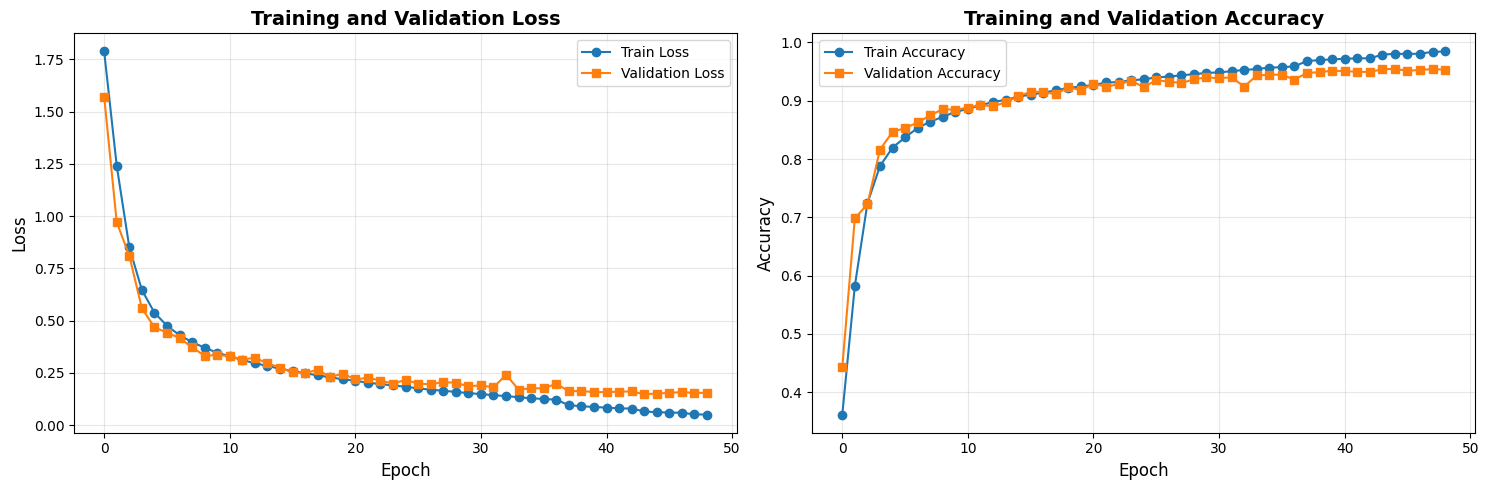


Final Training Results:
Best Validation Loss: 0.1482
Best Validation Accuracy: 0.9547
Final Training Loss: 0.0510
Final Training Accuracy: 0.9846



In [28]:
plot_training_history(history)

In [29]:
def predict_batch(model, test_dl, device, num_images=16):
    model.to(device)

    model.eval()

    # Get one batch
    images, labels = next(iter(test_dl))
    images = images.to(device)
    labels = labels.to(device)

    # Make predictions
    with torch.no_grad():
        logits = model(images)
        predictions = torch.argmax(logits, dim=1)
        probabilities = torch.softmax(logits, dim=1)

    # Move to CPU for plotting
    images = images.cpu()
    labels = labels.cpu()
    predictions = predictions.cpu()
    probabilities = probabilities.cpu()

    # Plot results
    num_images = min(num_images, len(images))
    rows = int(np.sqrt(num_images))
    cols = int(np.ceil(num_images / rows))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2.5))
    axes = axes.flatten() if num_images > 1 else [axes]

    for idx in range(num_images):
        ax = axes[idx]

        # Display image
        img = images[idx].squeeze()
        ax.imshow(img, cmap='gray')

        # Get prediction info
        pred = predictions[idx].item()
        true_label = labels[idx].item()
        confidence = probabilities[idx][pred].item()

        # Color code: green for correct, red for incorrect
        color = 'green' if pred == true_label else 'red'

        # Set title
        ax.set_title(f'True: {true_label}\nPred: {pred} ({confidence:.2%})',
                    color=color, fontsize=10, fontweight='bold')
        ax.axis('off')

    # Hide extra subplots
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Calculate accuracy for this batch
    correct = (predictions[:num_images] == labels[:num_images]).sum().item()
    accuracy = correct / num_images
    print(f"\nBatch Accuracy: {accuracy:.2%} ({correct}/{num_images} correct)")

In [33]:
vit_model_loaded = torch.compile(ViT())

vit_model_loaded.load_state_dict(torch.load("/content/best_vit.pth",
                                            map_location="cuda:0" if torch.cuda.is_available() else "cpu"))

<All keys matched successfully>

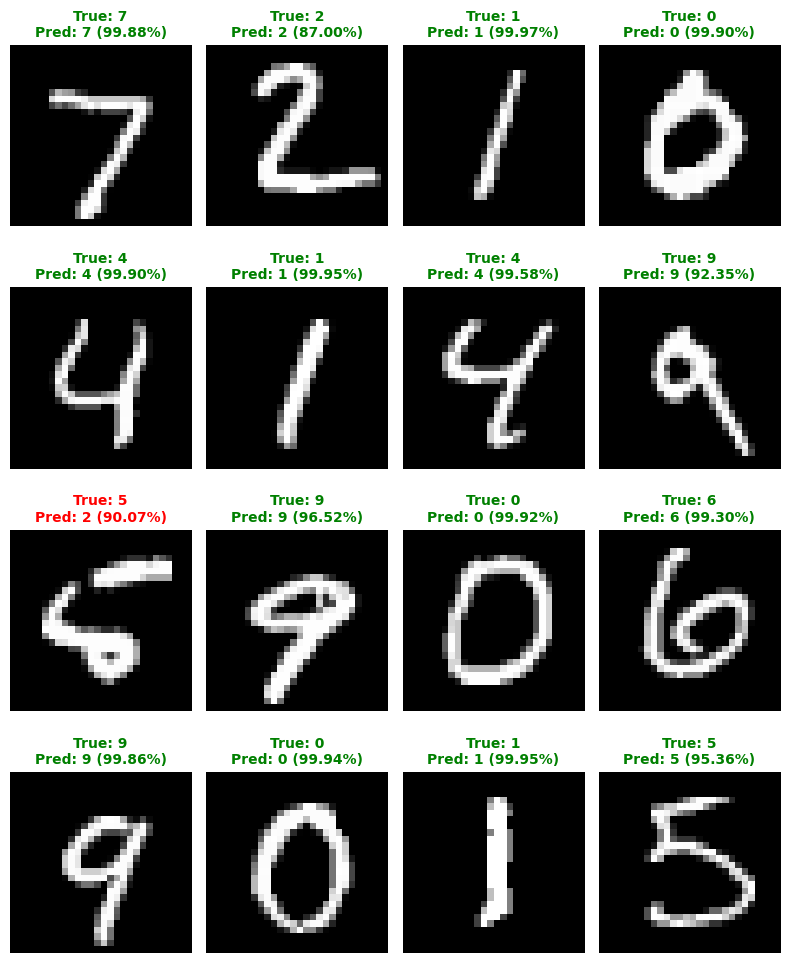


Batch Accuracy: 93.75% (15/16 correct)


In [34]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
predict_batch(vit_model_loaded, test_dl, device, num_images=16)